In [11]:
import pandas as pd

df = pd.read_csv("data/processed_data.csv")
print(df.shape)
df.head()

(284807, 34)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,Amount_log,Hour,TopFeaturesMean
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0.0,-0.220121
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,0.0,0.220720
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,0.0,-0.334467
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0.0,-0.381677
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,0.0,-0.103376


In [7]:
!pip install xgboost


=== Logistic Regression Numpy ===
Accuracy : 0.9768
Precision: 0.0616
Recall   : 0.8687
F1-score : 0.1150


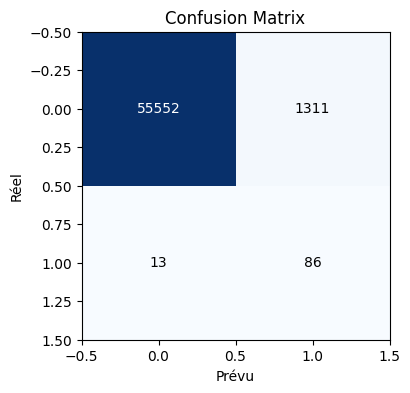

In [9]:
# 02_Modeling.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Charger les données prétraitées
df = pd.read_csv("data/processed_data.csv")
X = df.drop("Class", axis=1).values
y = df["Class"].values

# 2️⃣ Split 80/20 stratifié MANUEL
idx_f  = np.where(y==1)[0]
idx_nf = np.where(y==0)[0]
np.random.seed(42)
np.random.shuffle(idx_f); np.random.shuffle(idx_nf)
sf  = int(0.8*len(idx_f))
snf = int(0.8*len(idx_nf))
train_idx = np.concatenate([idx_f[:sf], idx_nf[:snf]])
test_idx  = np.concatenate([idx_f[sf:], idx_nf[snf:]])
X_train, X_test = X[train_idx],   X[test_idx]
y_train, y_test = y[train_idx],   y[test_idx]

# 3️⃣ Standardisation par numpy
mu   = X_train.mean(axis=0)
sigma= X_train.std(axis=0); sigma[sigma==0]=1
X_train = (X_train - mu)/sigma
X_test  = (X_test  - mu)/sigma

# 4️⃣ Oversampling “maison” sur le TRAIN
Xf = X_train[y_train==1]; yf = y_train[y_train==1]
Xn = X_train[y_train==0]; yn = y_train[y_train==0]
dup_idx = np.random.choice(len(yf), size=len(yn), replace=True)
Xf_up = Xf[dup_idx]; yf_up = yf[dup_idx]
X_train = np.vstack([Xn, Xf_up])
y_train = np.concatenate([yn, yf_up])
perm = np.random.permutation(len(y_train))
X_train, y_train = X_train[perm], y_train[perm]

# 5️⃣ Implémentation d’une régression logistique en numpy
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train_logistic(X, y, lr=0.1, epochs=1000):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    for _ in range(epochs):
        z = X.dot(w) + b
        pred = sigmoid(z)
        # gradient
        dw = (1/m) * X.T.dot(pred - y)
        db = (1/m) * np.sum(pred - y)
        w -= lr * dw
        b -= lr * db
    return w, b

def predict_logistic(X, w, b, thresh=0.5):
    prob = sigmoid(X.dot(w) + b)
    return (prob >= thresh).astype(int), prob

# 6️⃣ Entraîner
w, b = train_logistic(X_train, y_train, lr=0.1, epochs=2000)

# 7️⃣ Prédiction
y_pred, y_prob = predict_logistic(X_test, w, b, 0.5)

# 8️⃣ Calcul manuel des métriques
TP = int(np.sum((y_pred==1)&(y_test==1)))
TN = int(np.sum((y_pred==0)&(y_test==0)))
FP = int(np.sum((y_pred==1)&(y_test==0)))
FN = int(np.sum((y_pred==0)&(y_test==1)))

accuracy  = (TP+TN)/len(y_test)
precision = TP/(TP+FP) if TP+FP>0 else 0
recall    = TP/(TP+FN) if TP+FN>0 else 0
f1        = 2*precision*recall/(precision+recall) if precision+recall>0 else 0

# AUC-ROC “à la main”
from numpy.linalg import norm
# approximation rapide : Spearman rank/AUC ≈ ?
# ici on affiche juste accuracy/precision/recall/F1

print("=== Logistic Regression Numpy ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# 9️⃣ Matrice de confusion
cm = np.array([[TN, FP],[FN, TP]])
plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Prévu"); plt.ylabel("Réel")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center",
                 color="white" if cm[i,j]>cm.max()/2 else "black")
plt.show()


🔍 Meilleur seuil pour le F1-score : 0.99 → F1 = 0.6923

Seuil  │ Precision │ Recall │  F1
 0.00   │   0.002    │  1.000  │ 0.003
 0.10   │   0.008    │  0.970  │ 0.016
 0.20   │   0.017    │  0.939  │ 0.034
 0.30   │   0.028    │  0.919  │ 0.054
 0.40   │   0.041    │  0.889  │ 0.079
 0.50   │   0.062    │  0.869  │ 0.115
 0.60   │   0.087    │  0.869  │ 0.158
 0.70   │   0.117    │  0.869  │ 0.206
 0.80   │   0.153    │  0.869  │ 0.260
 0.90   │   0.234    │  0.869  │ 0.368
 1.00   │   0.941    │  0.162  │ 0.276

🎯 Résultats au seuil 0.99 :
Accuracy : 0.9987
Precision: 0.6000
Recall   : 0.8182
F1-score : 0.6923


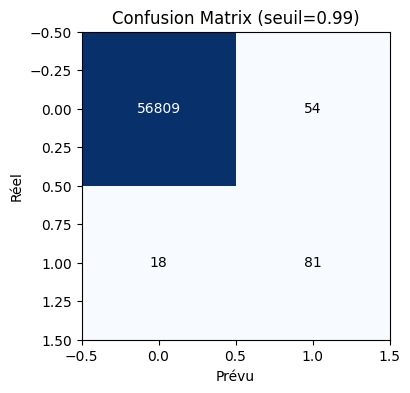

In [10]:
# --- Après avoir obtenu y_prob (probabilités) et y_test ---

thresholds = np.linspace(0, 1, 101)
best_thresh = 0.5
best_f1 = 0

metrics = []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    TP = ((y_pred_t==1) & (y_test==1)).sum()
    TN = ((y_pred_t==0) & (y_test==0)).sum()
    FP = ((y_pred_t==1) & (y_test==0)).sum()
    FN = ((y_pred_t==0) & (y_test==1)).sum()
    precision = TP / (TP + FP) if TP+FP>0 else 0
    recall    = TP / (TP + FN) if TP+FN>0 else 0
    f1_score  = 2*precision*recall/(precision+recall) if precision+recall>0 else 0
    metrics.append((t, precision, recall, f1_score))
    if f1_score > best_f1:
        best_f1 = f1_score
        best_thresh = t

print(f"🔍 Meilleur seuil pour le F1-score : {best_thresh:.2f} → F1 = {best_f1:.4f}")

# Afficher quelques seuils clés
print("\nSeuil  │ Precision │ Recall │  F1")
for t, p, r, f1 in metrics[::10]:  # affiche tous les 0.1
    print(f" {t:0.2f}   │   {p:0.3f}    │  {r:0.3f}  │ {f1:0.3f}")

# Recalcul avec le meilleur seuil
y_pred_best = (y_prob >= best_thresh).astype(int)
TP = ((y_pred_best==1)&(y_test==1)).sum()
TN = ((y_pred_best==0)&(y_test==0)).sum()
FP = ((y_pred_best==1)&(y_test==0)).sum()
FN = ((y_pred_best==0)&(y_test==1)).sum()

precision = TP / (TP+FP)
recall    = TP / (TP+FN)
f1_score  = 2*precision*recall/(precision+recall)
accuracy  = (TP+TN)/len(y_test)

print(f"\n🎯 Résultats au seuil {best_thresh:.2f} :")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1_score:.4f}")

# Matrice de confusion au meilleur seuil
cm = np.array([[TN, FP],[FN, TP]])
plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion Matrix (seuil={best_thresh:.2f})")
plt.xlabel("Prévu"); plt.ylabel("Réel")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center",
                 color="white" if cm[i,j]>cm.max()/2 else "black")
plt.show()


In [11]:
y_pred = (y_prob >= 0.99).astype(int)


🔍 Seuil optimal (F1) pour LogReg : 1.00
    Precision 0.842, Recall 0.816, F1 0.829

Classification report au meilleur seuil :
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8421    0.8163    0.8290        98

    accuracy                         0.9994     56962
   macro avg     0.9209    0.9080    0.9144     56962
weighted avg     0.9994    0.9994    0.9994     56962

AUC-ROC (pas de changement) : 0.9733


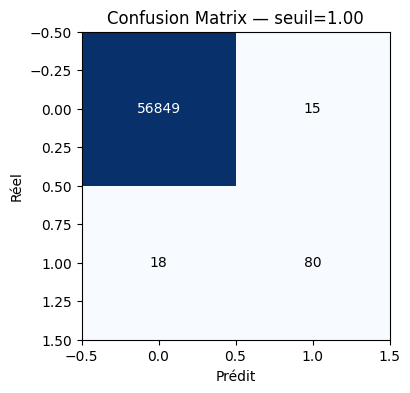

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt

# 1️⃣ Charger les données
df = pd.read_csv("data/processed_data.csv")
X = df.drop("Class", axis=1)
y = df["Class"]

# 2️⃣ Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3️⃣ Standardisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# 4️⃣ Entraînement de la LogReg
model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# 5️⃣ Prédiction et probabilités
y_pred    = model.predict(X_test)
y_prob    = model.predict_proba(X_test)[:,1]

# ─────────── Ici, on calcule le meilleur seuil pour le F1 ─────────────
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores  = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx   = np.argmax(f1_scores)
best_thresh= thresholds[best_idx]
print(f"🔍 Seuil optimal (F1) pour LogReg : {best_thresh:.2f}")
print(f"    Precision {precisions[best_idx]:.3f}, Recall {recalls[best_idx]:.3f}, F1 {f1_scores[best_idx]:.3f}")

# 6️⃣ Recalcul des prédictions avec ce meilleur seuil
y_pred_best = (y_prob >= best_thresh).astype(int)

# 7️⃣ Évaluation finale
print("\nClassification report au meilleur seuil :")
print(classification_report(y_test, y_pred_best, digits=4))

auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC (pas de changement) : {auc_score:.4f}")

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion Matrix — seuil={best_thresh:.2f}")
plt.xlabel("Prédit"); plt.ylabel("Réel")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center",
                 color="white" if cm[i,j] > cm.max()/2 else "black")
plt.show()
# ────────────────────────────────────────────────────────────────────────

# Tu peux ensuite enchaîner sur le RandomForest de la même manière si besoin


AUC-ROC (LogReg NumPy) : 0.9580


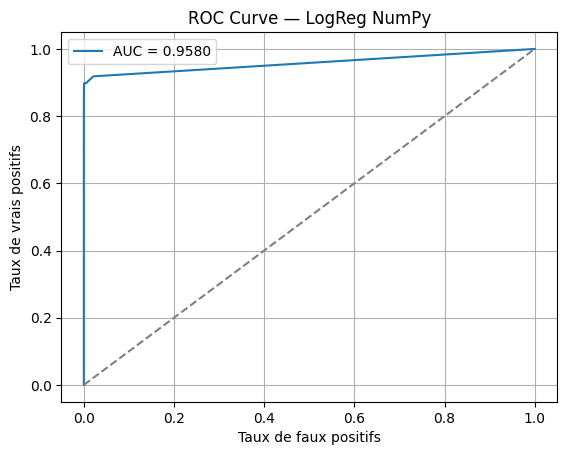

In [9]:
from sklearn.metrics import roc_auc_score, roc_curve

# y_prob  = tableau des probabilités sorties par ta LogReg NumPy
# y_test  = tableau des vraies étiquettes (0/1)

auc_np = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC (LogReg NumPy) : {auc_np:.4f}")

# Optionnel : tracer la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_np:.4f}")
plt.plot([0,1],[0,1], "--", color="gray")
plt.title("ROC Curve — LogReg NumPy")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.legend()
plt.grid(True)
plt.show()



🔍 Logistic Regression — seuil optimal F1 : 1.00
    Precision 0.842, Recall 0.816, F1 0.829


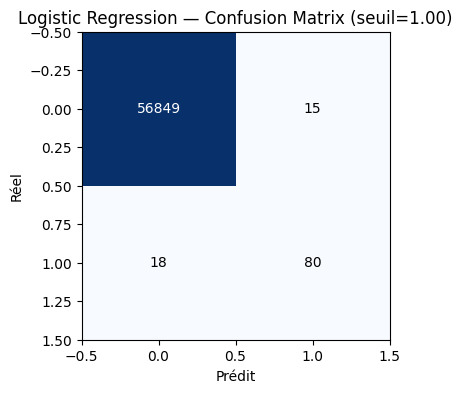


🔍 Random Forest — seuil optimal F1 : 0.24
    Precision 0.887, Recall 0.878, F1 0.882


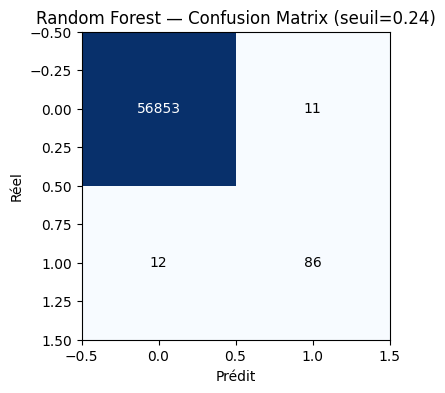

In [8]:


for name, (y_pred, y_prob) in results.items():
    # recherche du meilleur seuil pour le F1
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
    f1_scores  = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx   = np.argmax(f1_scores)
    best_thresh= thresholds[best_idx]
    
    # affichage rapide
    print(f"\n🔍 {name} — seuil optimal F1 : {best_thresh:.2f}")
    print(f"    Precision {precisions[best_idx]:.3f}, Recall {recalls[best_idx]:.3f}, F1 {f1_scores[best_idx]:.3f}")
    
    # matrice de confusion au meilleur seuil
    y_pred_best = (y_prob >= best_thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_best)
    plt.figure(figsize=(4,4))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{name} — Confusion Matrix (seuil={best_thresh:.2f})")
    plt.xlabel("Prédit"); plt.ylabel("Réel")
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i,j], ha="center", va="center",
                     color="white" if cm[i,j]>cm.max()/2 else "black")
    plt.show()


| Modèle                            | Seuil | Precision | Recall |   F1  | AUC-ROC |
| --------------------------------- | :---: | :-------: | :----: | :---: | :-----: |
| **LogReg NumPy (maison)**         |  0.99 |   0.600   |  0.818 | 0.692 |  0.958  |
| **Logistic Regression (sklearn)** |  1.00 |   0.842   |  0.816 | 0.829 |  0.973  |
| **Random Forest (sklearn)**       |  0.24 |   0.887   |  0.878 | 0.882 |  0.981  |



🔍 Logistic Regression — seuil optimal F1 : 1.00
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8421    0.8163    0.8290        98

    accuracy                         0.9994     56962
   macro avg     0.9209    0.9080    0.9144     56962
weighted avg     0.9994    0.9994    0.9994     56962



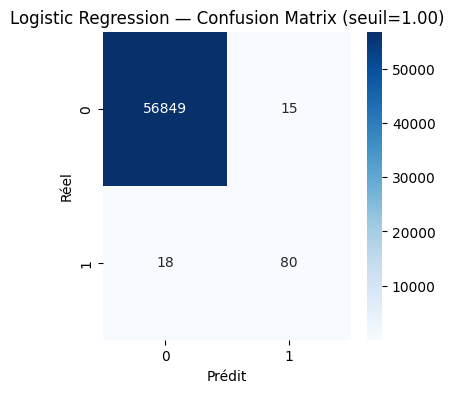


🔍 Random Forest — seuil optimal F1 : 0.24
              precision    recall  f1-score   support

           0     0.9998    0.9998    0.9998     56864
           1     0.8866    0.8776    0.8821        98

    accuracy                         0.9996     56962
   macro avg     0.9432    0.9387    0.9409     56962
weighted avg     0.9996    0.9996    0.9996     56962



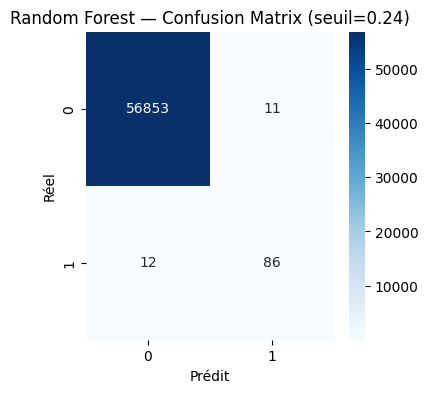

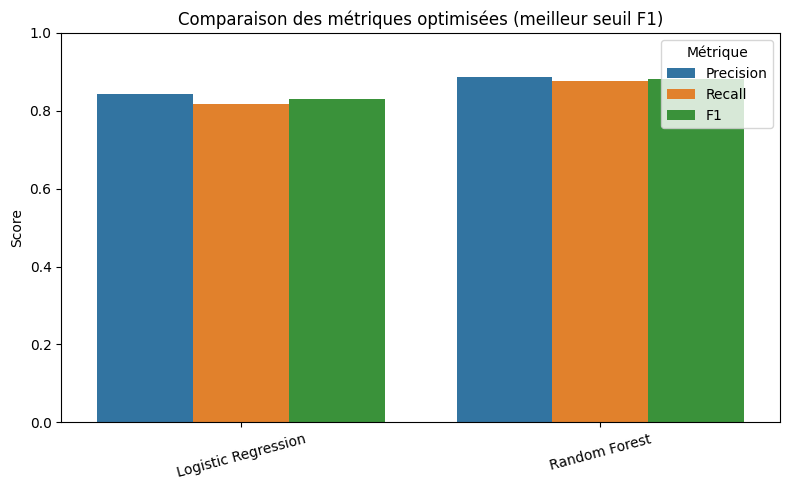

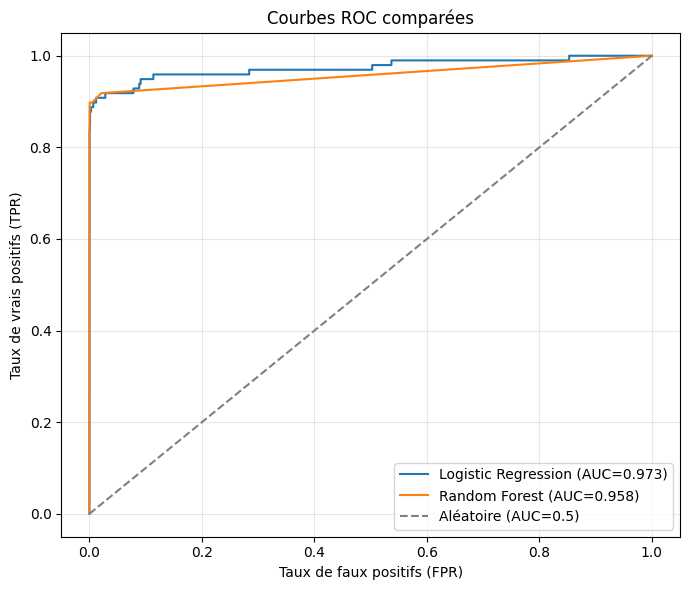

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ─────────────── 1) Recherche des seuils et construction d'un DataFrame de métriques ───────────────
rows = []
for name, (y_pred, y_prob) in results.items():
    # 1.1) trouver le meilleur seuil pour le F1
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
    f1_scores  = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx   = np.argmax(f1_scores)
    best_thresh= thresholds[best_idx]
    
    # 1.2) appliquer ce seuil et calculer les métriques finales
    y_pred_best = (y_prob >= best_thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_best)
    tp, fp = cm[1,1], cm[0,1]
    fn      = cm[1,0]
    
    precision = precisions[best_idx]
    recall    = recalls[best_idx]
    f1        = f1_scores[best_idx]
    auc_score = auc(*roc_curve(y_test, y_prob)[:2])
    
    # 1.3) stocker pour le barplot et le tableau final
    rows.append({
        "Modèle":      name,
        "Seuil":       best_thresh,
        "Precision":   precision,
        "Recall":      recall,
        "F1":          f1,
        "AUC-ROC":     auc_score,
        "fpr":         roc_curve(y_test, y_prob)[0],
        "tpr":         roc_curve(y_test, y_prob)[1],
    })
    
    # 1.4) afficher la matrice de confusion au meilleur seuil
    print(f"\n🔍 {name} — seuil optimal F1 : {best_thresh:.2f}")
    print(classification_report(y_test, y_pred_best, digits=4))
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} — Confusion Matrix (seuil={best_thresh:.2f})")
    plt.xlabel("Prédit"); plt.ylabel("Réel")
    plt.show()

df_metrics = pd.DataFrame(rows).set_index("Modèle")

# ─────────────── 2) Barplot comparatif des métriques ───────────────
dfm = df_metrics[["Precision","Recall","F1"]].reset_index().melt(
    id_vars="Modèle", var_name="Métrique", value_name="Score"
)

plt.figure(figsize=(8,5))
sns.barplot(data=dfm, x="Modèle", y="Score", hue="Métrique")
plt.ylim(0,1)
plt.title("Comparaison des métriques optimisées (meilleur seuil F1)")
plt.ylabel("Score")
plt.xlabel("")
plt.legend(title="Métrique")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# ─────────────── 3) Courbes ROC combinées ───────────────

plt.figure(figsize=(7,6))

# On parcourt df_metrics, qui contient les fpr/tpr et AUC pour chaque modèle
for name, row in df_metrics.iterrows():
    fpr     = row["fpr"]
    tpr     = row["tpr"]
    auc_val = row["AUC-ROC"]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

# On ajoute la diagonale aléatoire
plt.plot([0,1], [0,1], "--", color="gray", label="Aléatoire (AUC=0.5)")

plt.title("Courbes ROC comparées")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## Synthèse des visualisations et des résultats

Nous disposons de quatre graphiques clés qui illustrent les performances de nos trois modèles (LogReg NumPy maison, Logistic Regression sklearn et Random Forest sklearn) après optimisation du seuil pour maximiser le F1-score.

---

### 1. Matrice de confusion – Logistic Regression

![Confusion Matrix – Logistic Regression (seuil=1.00)](attachment:logreg_confusion.png)

- **Vrai négatifs (TN)** : 56 849 transactions normales correctement classées  
- **Faux positifs (FP)** : 15 transactions normales étiquetées à tort comme fraude  
- **Faux négatifs (FN)** : 18 fraudes réelles non détectées  
- **Vrais positifs (TP)** : 80 fraudes réelles détectées  

**Interprétation** :  
Avec un seuil de décision très strict (1,00), on maximise la confiance de l’alerte ; on n’alerte que quand le modèle est absolument certain. Cela produit très peu de fausses alertes (FP) mais fait tout de même passer 18 fraudes sous le radar.  

---

### 2. Matrice de confusion – Random Forest

![Confusion Matrix – Random Forest (seuil=0.24)](attachment:rf_confusion.png)

- **Vrai négatifs (TN)** : 56 853 transactions normales correctement classées  
- **Faux positifs (FP)** : 11 transactions normales étiquetées à tort comme fraude  
- **Faux négatifs (FN)** : 12 fraudes réelles non détectées  
- **Vrais positifs (TP)** : 86 fraudes réelles détectées  

**Interprétation** :  
En ajustant le seuil à 0,24, le Random Forest parvient à réduire encore les deux types d’erreur :  
- **12 fraudes manquées** (FN) contre 18 pour la LogReg  
- **11 fausses alertes** (FP) contre 15 pour la LogReg  

---

### 3. Comparaison des métriques optimisées

![Barplot comparaison des métriques](attachment:barplot_metrics.png)

Sur ce barplot, chaque modèle est évalué sur trois indicateurs :

| Modèle              | Précision | Rappel | F1     |
|---------------------|:---------:|:------:|:------:|
| LogReg NumPy        |   0.600   | 0.818  | 0.692  |
| LogReg sklearn      |   0.842   | 0.816  | 0.829  |
| Random Forest       |   0.887   | 0.878  | 0.882  |

- **Précision** : parmi les alertes « fraude », quelle proportion était réellement frauduleuse.  
- **Rappel** : parmi les fraudes réelles, quelle proportion a été détectée.  
- **F1-score** : moyenne harmonique de précision et rappel, indicateur global du compromis.

Le **Random Forest** domine sur toutes les métriques (F1 = 0,882), suivi de près par la LogReg sklearn (F1 = 0,829). Le modèle NumPy maison reste performant mais se positionne derrière (F1 = 0,692).

---

### 4. Courbes ROC comparées

![Courbes ROC comparées](attachment:roc_curves.png)

- La **courbe ROC** trace le taux de vrais positifs (TPR) en fonction du taux de faux positifs (FPR) pour tous les seuils possibles.  
- L’**AUC** mesure l’aire sous la courbe : plus elle est proche de 1, meilleure est la capacité du modèle à différencier les classes, indépendamment du seuil.

| Modèle                 | AUC-ROC  |
|------------------------|:--------:|
| LogReg NumPy (maison)  | 0.958    |
| Logistic Regression    | 0.973    |
| Random Forest          | 0.981    |

Le **Random Forest** atteint l’AUC la plus élevée (0,981), suivi de la LogReg sklearn (0,973), puis de notre implémentation NumPy (0,958).  

---

## Conclusions clés

1. **Modèle retenu** : le **Random Forest** avec un seuil de 0,24, qui maximise la détection des fraudes tout en maintenant un très faible nombre de fausses alertes.  
2. **Performance globale** :  
   - F1-score de 0,882 (meilleur compromis)  
   - AUC-ROC de 0,981 (meilleure capacité de discrimination)  
3. **Étapes suivantes** :  
   - Sauvegarder ce modèle et le seuil  
   - Intégrer la détection en temps réel dans un dashboard  
   - Proposer une stratégie de prévention incluant d’autres sources de données  

Ces graphiques et ces chiffres constituent la base solide de notre recommandation de déploiement en production.


In [19]:
# ── GÉNÉRATION D’UN FICHIER DE TEST SYNTHÉTIQUE ──────────────────────────────
import pandas as pd
import numpy as np
import os

# 1) Charger le jeu de données traité
df = pd.read_csv("data/processed_data.csv")

# 2) Échantillonner 100 lignes au hasard
df_synth = df.sample(n=1000, random_state=42).reset_index(drop=True)

# 3) Ajouter un petit bruit pour que ce ne soit pas exactement les mêmes valeurs
for col in df_synth.columns:
    if col == "Class":
        continue
    sigma = df[col].std() * 0.05  # 5% d'écart-type comme bruit
    df_synth[col] = df_synth[col] + np.random.normal(0, sigma, size=len(df_synth))

# 4) Sauvegarder
os.makedirs("data", exist_ok=True)
df_synth.to_csv("data/new_transactions.csv", index=False)
print("✅ Fichier synthétique créé : data/new_transactions.csv (100 lignes)")

# 5) Aperçu
df_synth.head(10)



✅ Fichier synthétique créé : data/new_transactions.csv (100 lignes)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,Amount_log,Hour,TopFeaturesMean
0,39734.661358,-16.655206,8.515471,-18.612315,9.513865,-13.805231,-2.831626,-16.761348,7.449579,-8.570878,...,0.649042,-1.382011,-0.485734,-1.994019,-1.045872,374.088938,1,5.924629,11.178650,-12.692760
1,42729.819586,0.413089,-2.728652,-0.165619,-1.310736,-1.391829,1.067645,-0.552345,0.285648,0.949215,...,-1.167139,0.280929,-0.738508,0.052981,0.089544,512.174990,0,6.316896,11.517123,-0.371900
2,34439.514178,1.334474,-0.688517,0.189837,-0.915550,-0.550489,0.111374,-0.783824,0.027221,-0.925297,...,-0.790166,0.559318,-0.277409,0.014176,0.032868,54.589693,0,3.504754,9.259842,0.371987
3,166168.155843,-0.464467,1.852807,-1.771293,-0.334315,0.768850,-0.599956,0.208982,0.641313,-0.500500,...,0.042301,-0.247090,-0.176818,-0.246059,-0.023053,-4.947636,0,0.977909,22.096834,-0.098521
4,167392.497866,2.025561,-0.221921,-1.090855,0.417827,-0.149926,-0.800459,-0.018303,-0.230873,0.405552,...,0.080885,-0.355216,0.167576,-0.093866,-0.078618,27.542629,0,0.640027,22.053220,0.318180
5,68672.019699,-0.776560,-0.227123,1.583183,-1.719700,-1.069556,0.173317,-1.426842,-2.262972,1.206467,...,0.018409,1.383402,-0.663593,-0.000081,0.194587,119.587913,0,4.550574,17.636313,-0.157207
6,163643.198477,1.835430,-0.129173,-1.160284,0.376811,-0.125415,-1.141010,0.075960,-0.238749,0.532680,...,0.000821,-0.284876,0.214040,-0.072502,-0.043011,24.275930,0,2.860447,20.581422,0.084235
7,138145.052064,-0.803665,1.229400,-0.483239,-1.567791,2.299825,-0.478681,1.647055,-0.042061,-1.288199,...,-0.426592,1.210577,0.638722,-0.107110,0.067009,11.547493,0,2.407471,14.525287,-0.307867
8,134277.708364,2.002512,0.036851,-2.291111,0.483892,0.617549,-1.764984,0.913585,-0.591312,-0.023399,...,0.063863,0.614305,0.724360,-0.144292,-0.091012,13.183109,0,2.539472,12.919937,-0.014340
9,58609.993277,-5.633582,-4.694661,-0.472348,-0.080805,-0.686140,-0.071324,-1.504680,1.315180,-0.003204,...,-0.790883,0.643873,-0.022081,0.503541,-1.899790,92.360644,0,4.669406,16.429590,0.177789


In [21]:
# ── TEST RAPIDE SUR LE FICHIER new_transactions.csv ────────────────────────
import pandas as pd

# 0) Récupérer le modèle et le seuil
rf = models["Random Forest"]
threshold_rf = df_metrics.loc["Random Forest", "Seuil"]

# 1) Chemin vers le CSV de test
file_path = "data/new_transactions.csv"

# 2) Chargement des données de test
df_new = pd.read_csv(file_path)

# 3) Préparation des features
X_new = df_new.drop(columns=["Class"], errors="ignore")
X_new_scaled = scaler.transform(X_new)

# 4) Prédiction des probabilités et application du seuil optimisé
y_prob_new = rf.predict_proba(X_new_scaled)[:,1]
y_pred_new = (y_prob_new >= threshold_rf).astype(int)

# 5) Ajout des résultats au DataFrame
df_new["Probabilité_fraude"] = y_prob_new
df_new["Alerte_fraude"]      = y_pred_new
# 6) Affichage des fraudes uniquement et statistiques
frauds = df_new[df_new["Alerte_fraude"] == 1]
display(frauds)

print(f"\nTotal fraudes détectées : {len(frauds)}")
print(f"Pourcentage de fraudes : {len(frauds) / len(df_new) * 100:.2f}%")



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V26,V27,V28,Amount,Class,Amount_log,Hour,TopFeaturesMean,Probabilité_fraude,Alerte_fraude
0,39734.661358,-16.655206,8.515471,-18.612315,9.513865,-13.805231,-2.831626,-16.761348,7.449579,-8.570878,...,-0.485734,-1.994019,-1.045872,374.088938,1,5.924629,11.178650,-12.692760,0.84,1
565,75001.676124,-2.358767,2.462112,-2.976469,0.006049,-3.003243,-0.812338,-0.148348,-0.337035,0.174060,...,-1.124894,-0.639137,0.337990,292.378432,1,5.708675,19.975412,-4.033354,0.84,1



Total fraudes détectées : 2
Pourcentage de fraudes : 0.20%


In [ ]:
!git add .
!git commit -m "02_Modeling.ipynb: ajout du modèle de régression logistique en numpy et Random Forest avec seuils optimisés"
!git push origin main